# Warsaw Transit Telemetry: Exogenous Features Overview

This notebook visualizes the two **exogenous feature marts** engineered for Warsaw transit delay attribution:
1. **Meteorological Telemetry ([IMGW-PIB](https://danepubliczne.imgw.pl/))**: Hourly weather time-series (temperature, precipitation, wind gusts, humidity, pressure, freezing rain).
2. **Road Infrastructure Topology (OSMnx)**: Road network segment metrics across 4 core transit study corridors (*Puławska*, *Al. Jerozolimskie*, *Trasa W-Z*, *Towarowa/Okopowa*).

---

In [1]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica', 'Arial', 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Robust path resolution
if os.path.exists('../data/processed'):
    DATA_DIR = '../data'
elif os.path.exists('data/processed'):
    DATA_DIR = 'data'
else:
    DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))

WEATHER_PARQUET = os.path.join(DATA_DIR, 'processed/imgw_weather_hourly.parquet')
OSM_PARQUET = os.path.join(DATA_DIR, 'processed/osm_corridor_segments.parquet')
RAW_DATA_PATH = os.path.join(DATA_DIR, 'raw/**/*.parquet')

con = duckdb.connect(':memory:')
print('Exogenous datasets ready.')

Exogenous datasets ready.


## 1. IMGW-PIB Hourly Synoptic Weather Telemetry
Station: **Warsaw Okęcie** (WMO Station `12375` / ID `352200375`).

,timestamp,temperature_c,relative_humidity,precipitation_mm,wind_speed_ms,pressure_hpa,visibility_m
count,721,27.000000,721.000000,721.0,1.0,1.0,720.000000
mean,2026-09-16 00:18:58.418862,11.277778,8.119556,0.0,2.0,1010.4,37648.604167
min,2026-09-01 00:00:00,7.000000,8.000000,0.0,2.0,1010.4,300.000000
25%,2026-09-08 12:00:00,10.500000,8.000000,0.0,2.0,1010.4,25000.000000
50%,2026-09-16 00:00:00,12.000000,8.000000,0.0,2.0,1010.4,45993.500000
75%,2026-09-23 12:00:00,12.000000,8.000000,0.0,2.0,1010.4,50000.000000
max,2026-10-10 12:00:00,14.000000,94.200000,0.0,2.0,1010.4,50000.000000
std,NaN,1.799216,3.210256,0.0,NaN,NaN,14972.305418


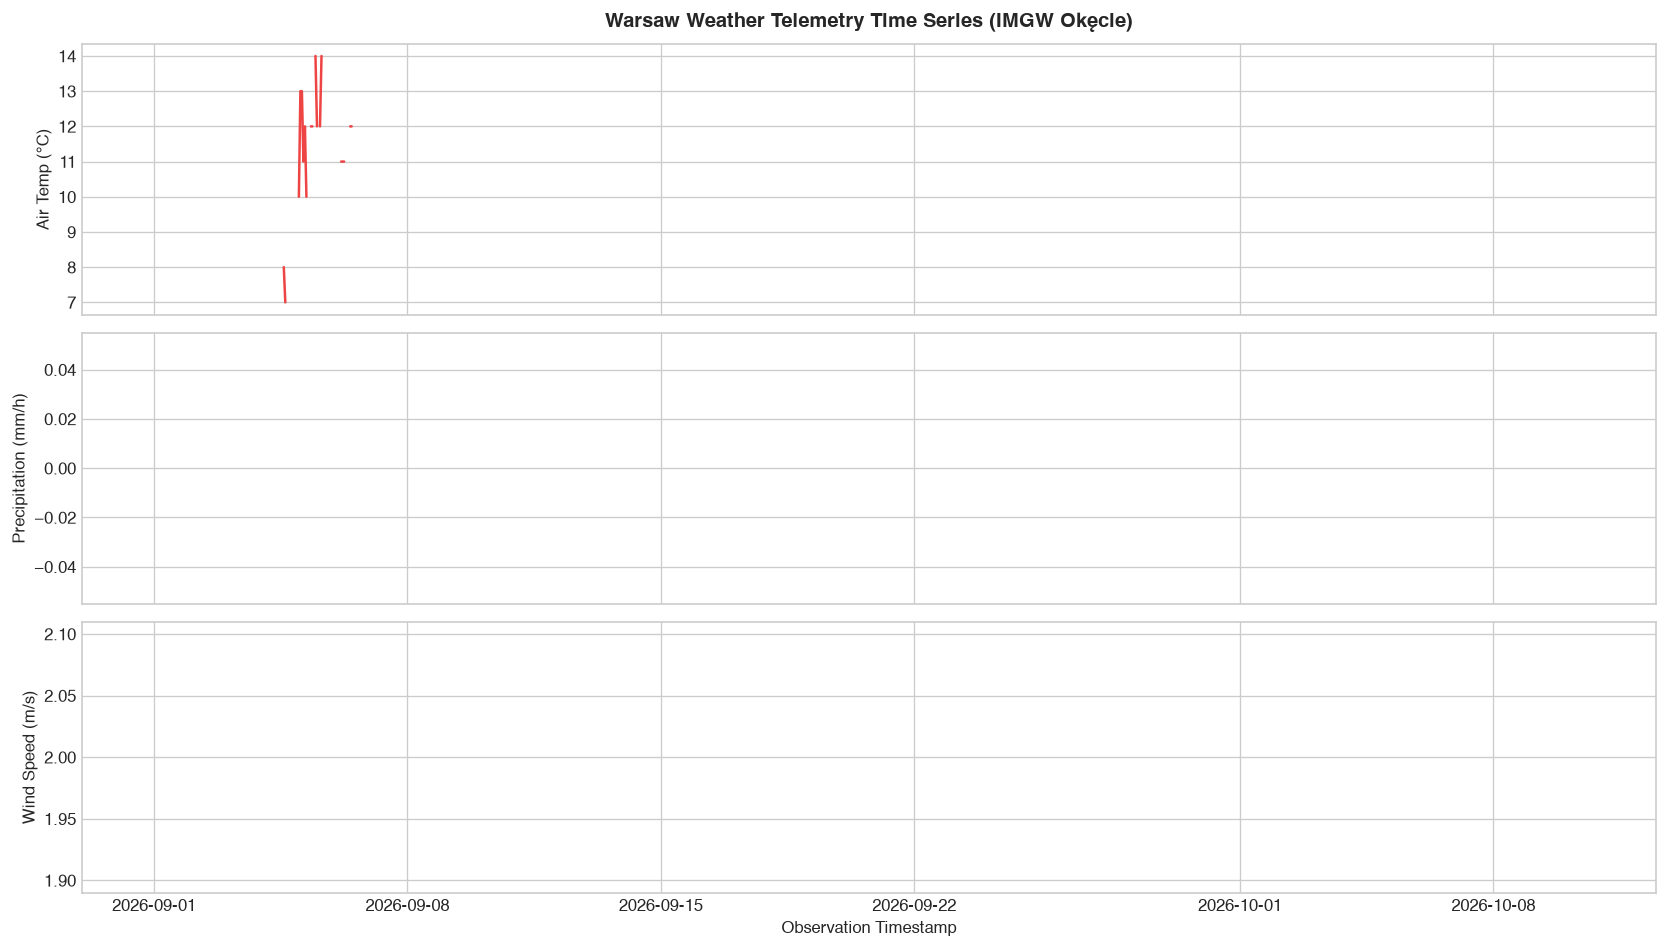

In [2]:
weather_df = con.execute(f'''
    SELECT 
        timestamp,
        temperature_c,
        relative_humidity,
        precipitation_mm,
        wind_speed_ms,
        pressure_hpa,
        visibility_m,
        freezing_rain_flag
    FROM read_parquet('{WEATHER_PARQUET}')
    ORDER BY timestamp
''').df()

display(weather_df.describe())

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Temperature
ax1.plot(weather_df['timestamp'], weather_df['temperature_c'], color='#ef4444', linewidth=1.5)
ax1.set_ylabel('Air Temp (°C)', fontsize=10)
ax1.set_title('Warsaw Weather Telemetry Time Series (IMGW Okęcie)', fontsize=12, fontweight='bold', pad=10)

# Precipitation
ax2.bar(weather_df['timestamp'], weather_df['precipitation_mm'], color='#3b82f6', width=0.03)
ax2.set_ylabel('Precipitation (mm/h)', fontsize=10)

# Wind Speed
ax3.plot(weather_df['timestamp'], weather_df['wind_speed_ms'], color='#10b981', linewidth=1.2)
ax3.set_ylabel('Wind Speed (m/s)', fontsize=10)
ax3.set_xlabel('Observation Timestamp', fontsize=10)

plt.tight_layout()
plt.show()

## 2. Road Network & Study Corridor Infrastructure Topology (OSMnx)
Attributes extracted for all adjacent stop segments along 4 core arteries:
- `segment_length_meters`: Physical edge distance
- `signalized_intersection_count`: Traffic signals mapped within segment envelope
- `is_dedicated_right_of_way`: Tram median tracks, bus lanes, PAT (*pas autobusowo-tramwajowy*)
- `lane_capacity`: Mixed-traffic lanes

,corridor_name,segment_count,corridor_km,mean_stop_spacing_m,total_signals,signals_per_km,avg_lanes,dedicated_row_pct
0,pulawska,70,34.65,494.9,239.0,6.90,3.0,100.0
1,al_jerozolimskie,62,34.68,559.3,304.0,8.77,3.0,100.0
2,trasa_wz,33,19.21,582.1,118.0,6.14,2.0,100.0
3,towarowa_okopowa,23,10.22,444.2,76.0,7.44,3.0,100.0


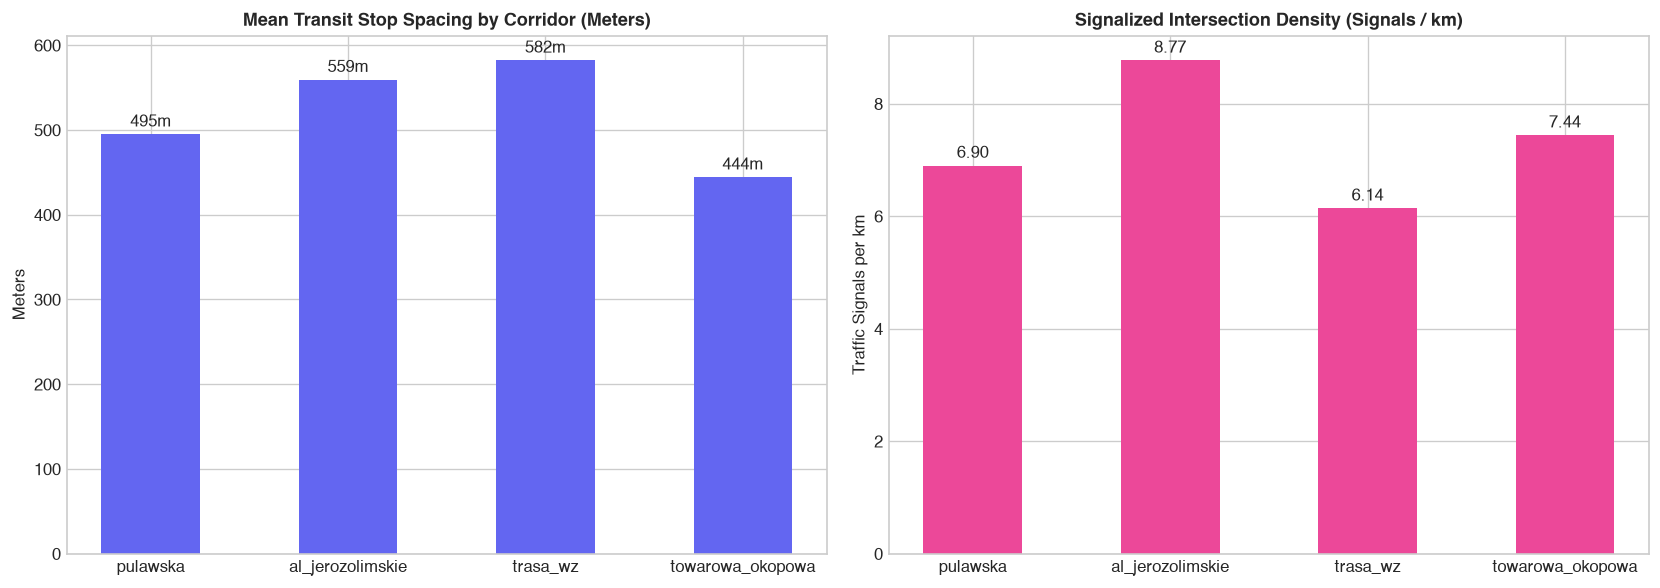

In [3]:
osm_df = con.execute(f'''
    SELECT 
        corridor_name,
        COUNT(*) AS segment_count,
        ROUND(SUM(segment_length_meters) / 1000.0, 2) AS corridor_km,
        ROUND(AVG(segment_length_meters), 1) AS mean_stop_spacing_m,
        SUM(signalized_intersection_count) AS total_signals,
        ROUND(SUM(signalized_intersection_count) / (SUM(segment_length_meters) / 1000.0), 2) AS signals_per_km,
        ROUND(AVG(lane_capacity), 1) AS avg_lanes,
        ROUND(100.0 * SUM(CASE WHEN is_dedicated_right_of_way THEN 1 ELSE 0 END) / COUNT(*), 1) AS dedicated_row_pct
    FROM read_parquet('{OSM_PARQUET}')
    GROUP BY corridor_name
    ORDER BY segment_count DESC
''').df()

display(osm_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Stop Spacing by Corridor
bars1 = ax1.bar(osm_df['corridor_name'], osm_df['mean_stop_spacing_m'], color='#6366f1', width=0.5)
ax1.set_title('Mean Transit Stop Spacing by Corridor (Meters)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Meters')
for b in bars1:
    h = b.get_height()
    ax1.annotate(f'{h:.0f}m', (b.get_x() + b.get_width()/2, h), ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

# Right: Signal Density
bars2 = ax2.bar(osm_df['corridor_name'], osm_df['signals_per_km'], color='#ec4899', width=0.5)
ax2.set_title('Signalized Intersection Density (Signals / km)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Traffic Signals per km')
for b in bars2:
    h = b.get_height()
    ax2.annotate(f'{h:.2f}', (b.get_x() + b.get_width()/2, h), ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

## 3. Preliminary Spatiotemporal Fusion Demonstration
Demonstrating how transit telemetry records join seamlessly with both weather conditions and physical road corridor attributes in DuckDB.

In [4]:
fusion_preview_df = con.execute(f'''
    SELECT 
        t.trip_id,
        t.route_id,
        t.stop_id,
        t.arrival_delay_seconds AS delay_s,
        to_timestamp(t.rt_arrival_time) AS arrival_time,
        w.temperature_c,
        w.precipitation_mm,
        osm.corridor_name,
        osm.segment_length_meters,
        osm.signalized_intersection_count AS signals,
        osm.is_dedicated_right_of_way AS dedicated_row
    FROM read_parquet('{RAW_DATA_PATH}', hive_partitioning=true) t
    JOIN read_parquet('{OSM_PARQUET}') osm ON CAST(t.stop_id AS VARCHAR) = CAST(osm.stop_id_curr AS VARCHAR)
    LEFT JOIN read_parquet('{WEATHER_PARQUET}') w ON date_trunc('hour', to_timestamp(t.rt_arrival_time)) = w.timestamp
    WHERE ABS(t.arrival_delay_seconds) <= 1800
    LIMIT 10
''').df()

print('Fused Spatiotemporal Record Sample:')
display(fusion_preview_df)

Fused Spatiotemporal Record Sample:


,trip_id,route_id,stop_id,delay_s,arrival_time,temperature_c,precipitation_mm,corridor_name,segment_length_meters,signals,dedicated_row
0,6586383-819857,27,500308,-26,2026-10-04 14:09:34+02:00,NaN,NaN,towarowa_okopowa,552.1,7,True
1,6721688-839699,1,508402,-13,2026-10-04 14:08:47+02:00,NaN,NaN,towarowa_okopowa,214.0,3,True
2,6883206-857993,9,700207,16,2026-10-04 14:09:16+02:00,NaN,NaN,al_jerozolimskie,622.5,11,True
3,6918473-863733,521,704102,30,2026-10-04 14:10:30+02:00,NaN,NaN,al_jerozolimskie,248.6,0,True
4,6881050-857858,512,100304,-18,2026-10-04 14:11:42+02:00,NaN,NaN,trasa_wz,476.1,8,True
5,6483887-811495,154,404571,-86,2026-10-04 14:10:34+02:00,NaN,NaN,al_jerozolimskie,345.3,0,True
6,6530848-816230,709,302301,114,2026-10-04 14:08:54+02:00,NaN,NaN,pulawska,628.3,3,True
7,6404316-803552,717,411402,8,2026-10-04 14:10:08+02:00,NaN,NaN,al_jerozolimskie,1378.1,0,True
8,6883917-858038,24,504006,-42,2026-10-04 14:10:18+02:00,NaN,NaN,towarowa_okopowa,407.2,5,True
9,6861507-856614,10,300972,0,2026-10-04 14:13:00+02:00,NaN,NaN,pulawska,101.2,1,True
